# Analyse du Risque de Crédit — Taiwanese Bankruptcy Prediction

## Analyse Comparative Entre Les Modèles De Rating De Risque De Crédit
**Projet de Fin d'Année — Bank of Africa, Business Center Agadir**

---

### Dataset Description
This notebook analyzes the **Taiwanese Bankruptcy Prediction** dataset from the Taiwan Economic Journal (TEJ),
covering **corporate financial data** from **1999 to 2009**.

- **Source**: [UCI ML Repository](https://archive-beta.ics.uci.edu/dataset/572/taiwanese+bankruptcy+prediction) / [Kaggle](https://www.kaggle.com/datasets/fedesoriano/company-bankruptcy-prediction/data)
- **Records**: 6,819 companies
- **Features**: 95 financial ratios (profitability, leverage, liquidity, activity, per-share, growth)
- **Target**: `Bankrupt?` — Whether the company went bankrupt (1=yes, 0=no)
- **Problem Type**: Binary Classification (highly imbalanced: ~3.2% bankruptcy rate)
- **Period**: 1999–2009

### Feature Categories (95 financial ratios)
| Category | Examples | Count |
|---|---|---|
| Profitability (ROA/ROE/Margins) | ROA(A/B/C), Operating Gross Margin, Net Income/TA | ~20 |
| Per-Share Metrics | Book Value/Share, EPS, Cash Flow/Share, Revenue/Share | ~8 |
| Growth Rates | Operating Profit Growth, Net Profit Growth, Asset Growth | ~9 |
| Liquidity | Current Ratio, Quick Ratio, Cash/TA, Cash/CL | ~12 |
| Leverage/Solvency | Debt Ratio, Liability/Equity, Interest Coverage | ~15 |
| Activity/Turnover | Asset Turnover, Receivable Turnover, Inventory Turnover | ~10 |
| Cash Flow | CFO/Assets, CF/Sales, CF/Equity, CF/Liability | ~8 |
| Flags & Other | Liability-Assets Flag, Net Income Flag, DFL | ~5 |

### Models Applied (4 Paradigms)
1. **Classical Econometric**: Logistic Regression, Probit, LDA, Altman Z-Score (partial)
2. **Machine Learning**: XGBoost, LightGBM, Random Forest, SVM, kNN, CART, MLP
3. **Structural & Market-Based**: Merton / KMV (N/A — explained)
4. **Dynamic Stochastic**: Markov Chains & Cox PH (N/A — explained)

## Setup

In [4]:
import subprocess, sys
for pkg in ['lightgbm', 'shap']:
    try: __import__(pkg)
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import *
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from statsmodels.stats.outliers_influence import variance_inflation_factor
import xgboost as xgb
import lightgbm as lgb
import statsmodels.api as sm
import shap
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## Phase 1 — Modeling Scope Framing

| Dimension | Description |
|---|---|
| **Scoring Type** | Corporate bankruptcy prediction (Acceptance/Wholesale scoring) |
| **Population** | 6,819 Taiwanese companies listed in the Taiwan Economic Journal |
| **Time Horizon** | 1999–2009 (10-year window) |
| **Data Structure** | Cross-sectional corporate financial ratios (95 features) |
| **Target** | Binary: Bankrupt (1) vs. Non-bankrupt (0) |
| **Imbalance** | ~3.2% bankruptcy rate — highly imbalanced |

This is a **corporate credit scoring** dataset. Companies are assessed using fundamental financial ratios
derived from balance sheets and income statements, making it directly relevant to **Bank of Africa's**
corporate lending and risk assessment activities.

---
## Phase 2 — Data Preparation and Cleansing

In [2]:
# Load the dataset
df = pd.read_csv('data.csv')
print(f'Dataset shape: {df.shape[0]} companies, {df.shape[1]} attributes')
print(f'Period: 1999-2009 (Taiwan Economic Journal)')
df.head()

Dataset shape: 6819 companies, 96 attributes
Period: 1999-2009 (Taiwan Economic Journal)


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [3]:
# Clean column names (remove leading spaces)
df.columns = df.columns.str.strip()
target_col = 'Bankrupt?'
print(f'Target: "{target_col}"')
print(f'Target distribution:\n{df[target_col].value_counts()}')
print(f'Bankruptcy rate: {df[target_col].mean():.2%}')

Target: "Bankrupt?"
Target distribution:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64
Bankruptcy rate: 3.23%


In [4]:
# Check duplicates and missing values
print(f'Duplicate rows: {df.duplicated().sum()}')
missing = df.isnull().sum()
print(f'Columns with missing values: {(missing > 0).sum()}')
if missing.sum() > 0:
    print(missing[missing > 0])

Duplicate rows: 0
Columns with missing values: 0


In [5]:
# Data info
print(f'All columns numeric: {all(df.dtypes != "object")}')
feature_cols = [c for c in df.columns if c != target_col]
print(f'Number of features: {len(feature_cols)}')

# Check for infinite values
inf_count = np.isinf(df[feature_cols]).sum().sum()
print(f'Infinite values: {inf_count}')
if inf_count > 0:
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
    df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())
    print('Replaced inf with median values.')

All columns numeric: True
Number of features: 95
Infinite values: 0


---
## Phase 3 — Sampling (Train/Test Split)

In [6]:
X = df.drop(target_col, axis=1)
y = df[target_col]

# Stratified 70/30 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale for models that need it
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f'Training set: {X_train.shape[0]} companies ({y_train.mean():.2%} bankruptcy rate)')
print(f'Test set:     {X_test.shape[0]} companies ({y_test.mean():.2%} bankruptcy rate)')

Training set: 4773 companies (3.23% bankruptcy rate)
Test set:     2046 companies (3.23% bankruptcy rate)


---
## Phase 4 — Variable Analysis
### 4.1 Descriptive Statistics

In [7]:
# Summary statistics for key features
key_features = ['ROA(C) before interest and depreciation before interest',
                'Operating Gross Margin', 'Debt ratio %', 'Current Ratio',
                'Total Asset Turnover', 'Retained Earnings to Total Assets',
                'Net Income to Total Assets', 'Working Capital to Total Assets',
                'Cash Flow to Total Assets', 'Equity to Liability']

# Use actual column names (they may differ slightly)
actual_keys = [c for c in df.columns if any(k.lower() in c.lower() for k in ['ROA(C)', 'Operating Gross', 'Debt ratio', 'Current Ratio', 'Total Asset Turnover', 'Retained Earnings to Total', 'Net Income to Total', 'Working Capital to Total', 'Cash Flow to Total', 'Equity to Liability'])]

if actual_keys:
    print(df[actual_keys].describe().round(4))
else:
    print(df.iloc[:, :10].describe().round(4))

       ROA(C) before interest and depreciation before interest  \
count                                          6819.0000         
mean                                              0.5052         
std                                               0.0607         
min                                               0.0000         
25%                                               0.4765         
50%                                               0.5027         
75%                                               0.5356         
max                                               1.0000         

       Operating Gross Margin  Current Ratio  Debt ratio %  \
count               6819.0000   6.819000e+03     6819.0000   
mean                   0.6079   4.032850e+05        0.1132   
std                    0.0169   3.330216e+07        0.0539   
min                    0.0000   0.000000e+00        0.0000   
25%                    0.6004   7.600000e-03        0.0729   
50%                    0.6060   1

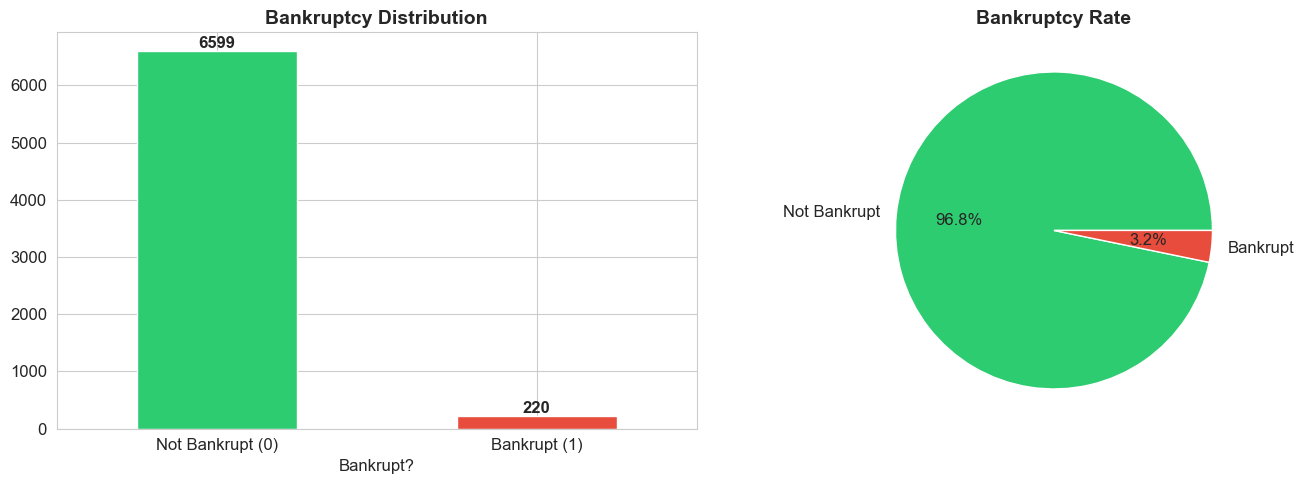

Severe class imbalance: only 3.23% of companies went bankrupt.


In [8]:
# Target distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Bankruptcy Distribution', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Not Bankrupt (0)', 'Bankrupt (1)'], rotation=0)
for i, v in enumerate(df[target_col].value_counts()):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

df[target_col].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                   colors=['#2ecc71', '#e74c3c'],
                                   labels=['Not Bankrupt', 'Bankrupt'])
axes[1].set_title('Bankruptcy Rate', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()
print(f'Severe class imbalance: only {df[target_col].mean():.2%} of companies went bankrupt.')

### 4.2 Correlation Analysis

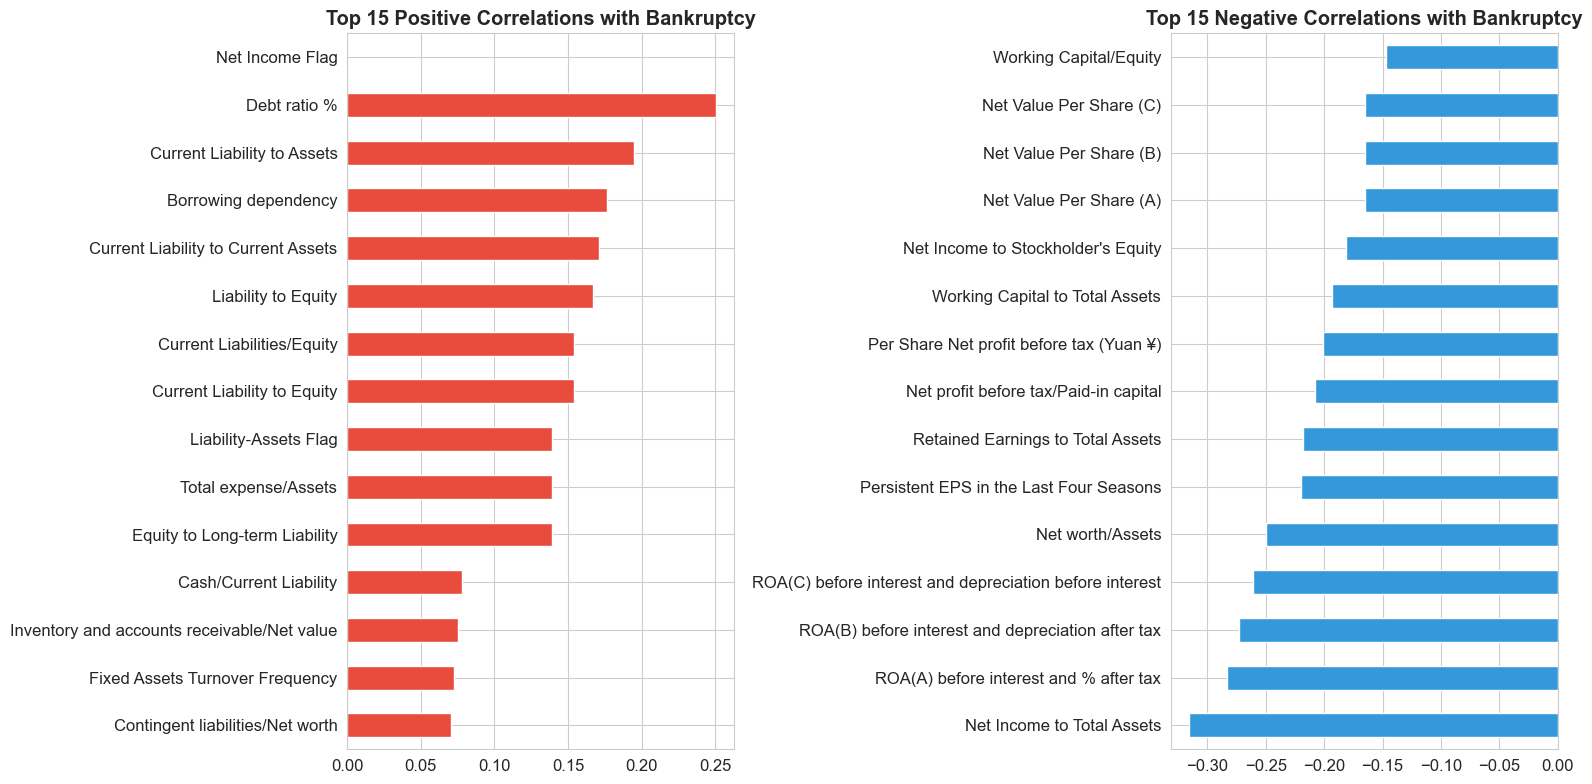

In [9]:
# Correlation with target
corr_target = df.corr(numeric_only=True)[target_col].drop(target_col).sort_values()

# Show top 15 and bottom 15
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top15 = corr_target.tail(15)
top15.plot(kind='barh', ax=axes[0], color='#e74c3c')
axes[0].set_title('Top 15 Positive Correlations with Bankruptcy', fontweight='bold')

bot15 = corr_target.head(15)
bot15.plot(kind='barh', ax=axes[1], color='#3498db')
axes[1].set_title('Top 15 Negative Correlations with Bankruptcy', fontweight='bold')

plt.tight_layout()
plt.show()

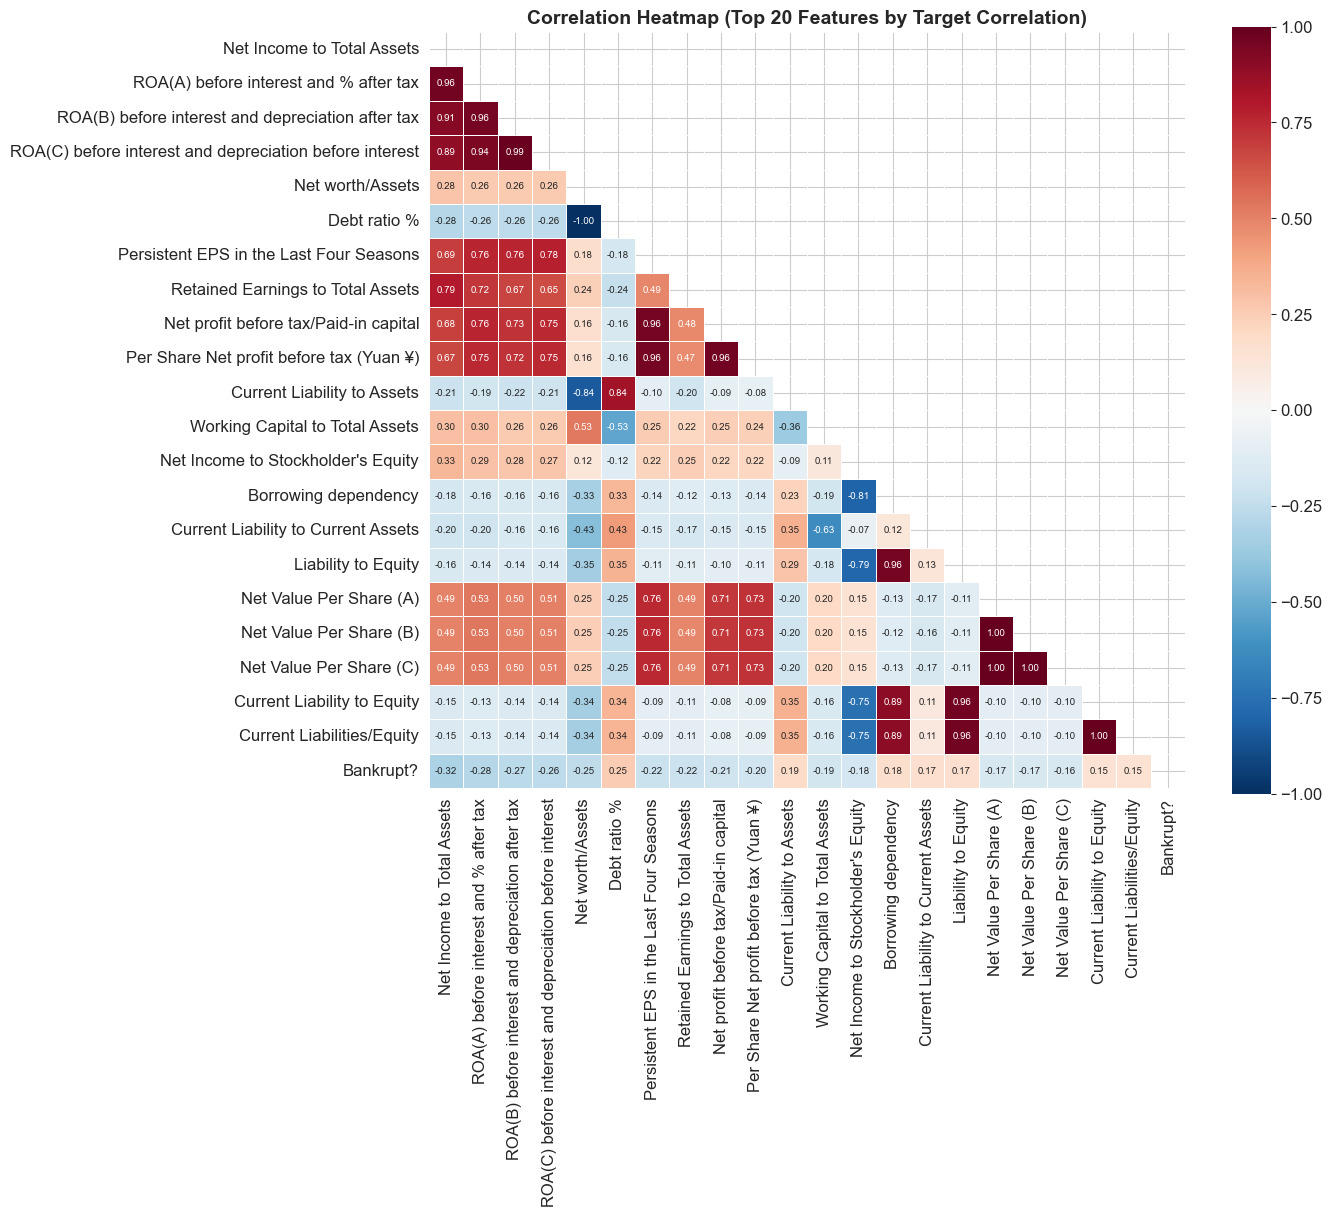

In [10]:
# Correlation heatmap (top 20 most correlated features)
top_corr_feats = corr_target.abs().nlargest(21).index.tolist()
if target_col not in top_corr_feats:
    top_corr_feats.append(target_col)

plt.figure(figsize=(14, 12))
corr_sub = df[top_corr_feats].corr()
mask = np.triu(np.ones_like(corr_sub, dtype=bool))
sns.heatmap(corr_sub, mask=mask, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', square=True, linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Heatmap (Top 20 Features by Target Correlation)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Phase 5 — Data Pre-processing
### 5.1 Information Value (IV)

In [11]:
def calculate_iv(df, feature, target, bins=10):
    d = df[[feature, target]].copy()
    try:
        if d[feature].nunique() > bins:
            d['bin'] = pd.qcut(d[feature], q=bins, duplicates='drop')
        else:
            d['bin'] = d[feature]
        g = d.groupby('bin', observed=True)[target].agg(['count', 'sum'])
        g.columns = ['total', 'events']
        g['non_events'] = g['total'] - g['events']
        te, tne = g['events'].sum(), g['non_events'].sum()
        g['er'] = g['events'].replace(0, 0.5) / te
        g['ner'] = g['non_events'].replace(0, 0.5) / tne
        g['woe'] = np.log(g['ner'] / g['er'])
        g['iv'] = (g['ner'] - g['er']) * g['woe']
        return g['iv'].sum()
    except:
        return 0

iv_values = {c: calculate_iv(pd.concat([X_train, y_train], axis=1), c, target_col) for c in feature_cols}
iv_df = pd.DataFrame({'Feature': list(iv_values.keys()), 'IV': list(iv_values.values())})
iv_df = iv_df.sort_values('IV', ascending=False).head(30)
iv_df['Strength'] = iv_df['IV'].apply(lambda x: 'Very Strong' if x >= 0.5 else 'Strong' if x >= 0.3 else 'Medium' if x >= 0.1 else 'Weak' if x >= 0.02 else 'Not useful')

print('Top 30 Features by Information Value:')
print(iv_df.to_string(index=False))

Top 30 Features by Information Value:
                                                Feature       IV    Strength
                Persistent EPS in the Last Four Seasons 2.591471 Very Strong
                                 Interest Expense Ratio 2.500056 Very Strong
                             Net Income to Total Assets 2.468087 Very Strong
                      Retained Earnings to Total Assets 2.452029 Very Strong
                  Net profit before tax/Paid-in capital 2.445493 Very Strong
               Per Share Net profit before tax (Yuan ¥) 2.439525 Very Strong
     Interest Coverage Ratio (Interest expense to EBIT) 2.429360 Very Strong
                   Continuous interest rate (after tax) 2.428448 Very Strong
                     Degree of Financial Leverage (DFL) 2.417373 Very Strong
                                   Borrowing dependency 2.326002 Very Strong
                             Total debt/Total net worth 2.269743 Very Strong
      ROA(B) before interest and depre

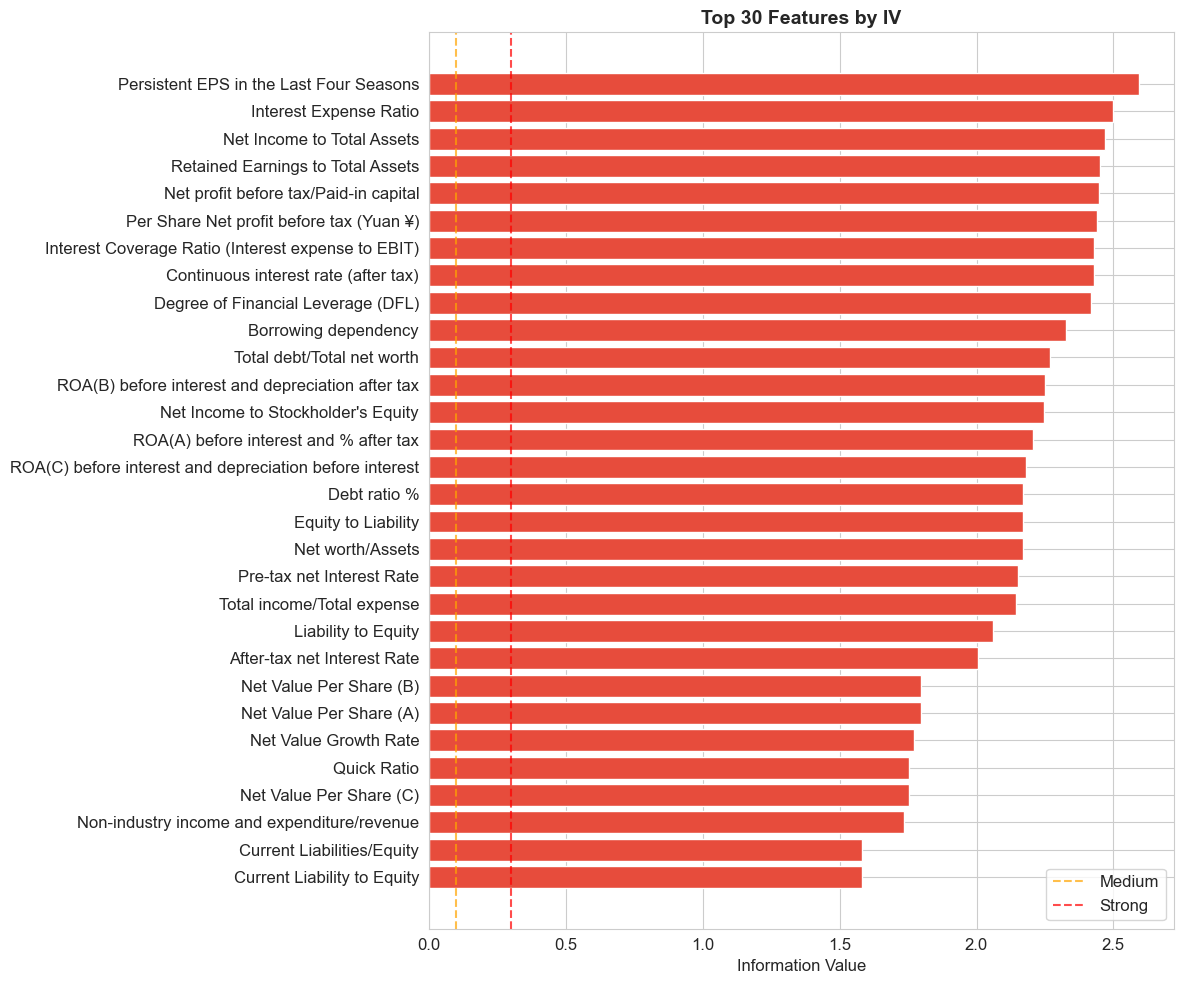

In [12]:
# IV visualization (top 30)
plt.figure(figsize=(12, 10))
colors = iv_df['IV'].apply(lambda x: '#e74c3c' if x >= 0.3 else '#f39c12' if x >= 0.1 else '#3498db' if x >= 0.02 else '#95a5a6')
plt.barh(iv_df['Feature'], iv_df['IV'], color=colors)
plt.xlabel('Information Value')
plt.title('Top 30 Features by IV', fontsize=14, fontweight='bold')
plt.axvline(x=0.1, color='orange', linestyle='--', alpha=0.7, label='Medium')
plt.axvline(x=0.3, color='red', linestyle='--', alpha=0.7, label='Strong')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 5.2 Feature Selection

With 95 features, we select the most informative ones to avoid overfitting and reduce dimensionality.

In [13]:
# Select features with IV >= 0.02 (at least weak predictive power)
all_iv = pd.DataFrame({'Feature': list(iv_values.keys()), 'IV': list(iv_values.values())})
selected_features = all_iv[all_iv['IV'] >= 0.02]['Feature'].tolist()
print(f'Features with IV >= 0.02: {len(selected_features)} out of {len(feature_cols)}')

# Use selected features for modeling
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

# Re-scale selected features
scaler_sel = StandardScaler()
X_train_sel_scaled = pd.DataFrame(scaler_sel.fit_transform(X_train_sel), columns=X_train_sel.columns, index=X_train_sel.index)
X_test_sel_scaled = pd.DataFrame(scaler_sel.transform(X_test_sel), columns=X_test_sel.columns, index=X_test_sel.index)

Features with IV >= 0.02: 94 out of 95


---
## Phase 6 — Modeling

In [14]:
results = {}
colors_plot = plt.cm.Set2(np.linspace(0, 1, 15))

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, paradigm='ML'):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = 1 / (1 + np.exp(-model.decision_function(X_te)))
    else:
        y_prob = y_pred.astype(float)
    acc = accuracy_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)
    gini = 2 * auc - 1
    f1 = f1_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred)
    brier = brier_score_loss(y_te, y_prob)
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    ks = max(tpr - fpr)
    results[name] = {'paradigm': paradigm, 'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
                      'accuracy': acc, 'auc': auc, 'gini': gini, 'ks': ks,
                      'f1': f1, 'precision': prec, 'recall': rec, 'brier': brier}
    print(f'  {name}: Acc={acc:.4f}  AUC={auc:.4f}  Gini={gini:.4f}  KS={ks:.4f}  F1={f1:.4f}  Brier={brier:.4f}')
    return model

print('Ready.')

Ready.


### 6.1 Paradigm 1 — Classical Econometric / Statistical

#### Logistic Regression

In [15]:
print('=== Paradigm 1: Classical Econometric ===')
evaluate_model('Logistic Regression',
               LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
               X_train_sel_scaled, X_test_sel_scaled, y_train, y_test, 'Econometric')

=== Paradigm 1: Classical Econometric ===
  Logistic Regression: Acc=0.8749  AUC=0.8836  Gini=0.7672  KS=0.6601  F1=0.2686  Brier=0.0895


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

#### Probit Model

In [16]:
'''
X_tr_c = sm.add_constant(X_train_sel_scaled)
X_te_c = sm.add_constant(X_test_sel_scaled)
probit_res = sm.Probit(y_train, X_tr_c).fit(disp=0, maxiter=100)
yp_prob = probit_res.predict(X_te_c)
yp_pred = (yp_prob >= 0.5).astype(int)
acc = accuracy_score(y_test, yp_pred); auc = roc_auc_score(y_test, yp_prob)
gini = 2*auc-1; f1v = f1_score(y_test, yp_pred, zero_division=0)
fpr_p, tpr_p, _ = roc_curve(y_test, yp_prob); ks = max(tpr_p - fpr_p)
brier = brier_score_loss(y_test, yp_prob)
results['Probit'] = {'paradigm': 'Econometric', 'model': probit_res, 'y_pred': yp_pred, 'y_prob': yp_prob,
                      'accuracy': acc, 'auc': auc, 'gini': gini, 'ks': ks,
                      'f1': f1v, 'precision': precision_score(y_test, yp_pred, zero_division=0),
                      'recall': recall_score(y_test, yp_pred), 'brier': brier}
print(f'  Probit: Acc={acc:.4f}  AUC={auc:.4f}  Gini={gini:.4f}  KS={ks:.4f}  F1={f1v:.4f}  Brier={brier:.4f}')
'''

"\nX_tr_c = sm.add_constant(X_train_sel_scaled)\nX_te_c = sm.add_constant(X_test_sel_scaled)\nprobit_res = sm.Probit(y_train, X_tr_c).fit(disp=0, maxiter=100)\nyp_prob = probit_res.predict(X_te_c)\nyp_pred = (yp_prob >= 0.5).astype(int)\nacc = accuracy_score(y_test, yp_pred); auc = roc_auc_score(y_test, yp_prob)\ngini = 2*auc-1; f1v = f1_score(y_test, yp_pred, zero_division=0)\nfpr_p, tpr_p, _ = roc_curve(y_test, yp_prob); ks = max(tpr_p - fpr_p)\nbrier = brier_score_loss(y_test, yp_prob)\nresults['Probit'] = {'paradigm': 'Econometric', 'model': probit_res, 'y_pred': yp_pred, 'y_prob': yp_prob,\n                      'accuracy': acc, 'auc': auc, 'gini': gini, 'ks': ks,\n                      'f1': f1v, 'precision': precision_score(y_test, yp_pred, zero_division=0),\n                      'recall': recall_score(y_test, yp_pred), 'brier': brier}\nprint(f'  Probit: Acc={acc:.4f}  AUC={auc:.4f}  Gini={gini:.4f}  KS={ks:.4f}  F1={f1v:.4f}  Brier={brier:.4f}')\n"

#### Linear Discriminant Analysis (LDA)

In [17]:
evaluate_model('LDA', LinearDiscriminantAnalysis(),
               X_train_sel_scaled, X_test_sel_scaled, y_train, y_test, 'Econometric')

  LDA: Acc=0.9599  AUC=0.9060  Gini=0.8120  KS=0.7066  F1=0.3387  Brier=0.0341


,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


#### Altman Z-Score

> **PARTIALLY APPLICABLE.** The Taiwan dataset contains several ratios that correspond
> to Altman Z-Score components, but not a perfect mapping:
>
> | Altman Component | Formula | Taiwan Feature | Match |
> |---|---|---|---|
> | X₁ | Working Capital / Total Assets | `Working Capital to Total Assets` (X54) | ✅ Direct |
> | X₂ | Retained Earnings / Total Assets | `Retained Earnings to Total Assets` (X68) | ✅ Direct |
> | X₃ | EBIT / Total Assets | Closest: `ROA(C)` or `Net Income to Total Assets` (X86) | ⚠️ Proxy |
> | X₄ | Market Value Equity / Book Value Debt | No market value data available | ❌ Missing |
> | X₅ | Sales / Total Assets | `Total Asset Turnover` (X45) | ✅ Direct |
>
> We compute a **modified Z-Score** using the available ratios, noting that X₄ is approximated
> using `Equity to Liability` as a proxy (book value instead of market value).

  X1: Working Capital to Total Assets
  X2: Retained Earnings to Total Assets
  X3: Net Income to Total Assets
  X4: Equity to Liability
  X5: Total Asset Turnover
  Altman Z-Score (Modified): Acc=0.9677  AUC=0.9097  KS=0.6707  F1=0.0000
  NOTE: Uses book-value proxy for X4 (no market value data available).


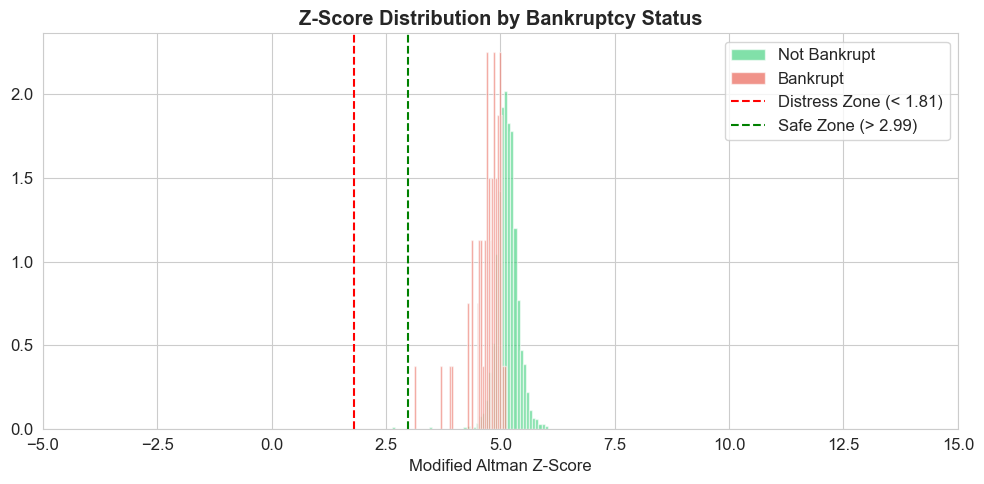

In [18]:
# Modified Altman Z-Score computation
# Z = 0.012*X1 + 0.014*X2 + 0.033*X3 + 0.006*X4 + 0.999*X5
# Using Altman's original coefficients (multiplied by 100 in some formulations)

z_cols = {
    'X1': 'Working Capital to Total Assets',
    'X2': 'Retained Earnings to Total Assets',
    'X3': 'Net Income to Total Assets',  # Proxy for EBIT/TA
    'X4': 'Equity to Liability',          # Proxy for MV Equity/BV Debt
    'X5': 'Total Asset Turnover'
}

# Find actual column names
z_mapping = {}
for key, search in z_cols.items():
    matches = [c for c in df.columns if search.lower() in c.lower()]
    if matches:
        z_mapping[key] = matches[0]
        print(f'  {key}: {matches[0]}')
    else:
        print(f'  {key}: NOT FOUND ({search})')

if len(z_mapping) >= 4:
    # Compute Z-Score
    z_test = X_test.copy()
    z_score = (1.2 * z_test[z_mapping['X1']] +
               1.4 * z_test[z_mapping['X2']] +
               3.3 * z_test[z_mapping['X3']] +
               0.6 * z_test[z_mapping['X4']] +
               1.0 * z_test[z_mapping['X5']])

    # Classify: Z < 1.81 = Distress (bankrupt), Z > 2.99 = Safe, else = Grey
    z_pred = (z_score < 1.81).astype(int)
    z_prob = 1 / (1 + np.exp(z_score - 1.81))  # Sigmoid around cutoff

    acc = accuracy_score(y_test, z_pred)
    try:
        auc = roc_auc_score(y_test, z_prob)
    except:
        auc = 0.5
    gini = 2*auc-1
    f1v = f1_score(y_test, z_pred, zero_division=0)
    brier = brier_score_loss(y_test, z_prob)
    fpr_z, tpr_z, _ = roc_curve(y_test, z_prob)
    ks = max(tpr_z - fpr_z)
    results['Altman Z-Score (Modified)'] = {
        'paradigm': 'Econometric', 'model': None, 'y_pred': z_pred, 'y_prob': z_prob,
        'accuracy': acc, 'auc': auc, 'gini': gini, 'ks': ks,
        'f1': f1v, 'precision': precision_score(y_test, z_pred, zero_division=0),
        'recall': recall_score(y_test, z_pred, zero_division=0), 'brier': brier
    }
    print(f'  Altman Z-Score (Modified): Acc={acc:.4f}  AUC={auc:.4f}  KS={ks:.4f}  F1={f1v:.4f}')
    print(f'  NOTE: Uses book-value proxy for X4 (no market value data available).')

    # Distribution of Z-Scores
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(z_score[y_test == 0], bins=50, alpha=0.6, label='Not Bankrupt', color='#2ecc71', density=True)
    ax.hist(z_score[y_test == 1], bins=50, alpha=0.6, label='Bankrupt', color='#e74c3c', density=True)
    ax.axvline(x=1.81, color='red', linestyle='--', label='Distress Zone (< 1.81)')
    ax.axvline(x=2.99, color='green', linestyle='--', label='Safe Zone (> 2.99)')
    ax.set_xlabel('Modified Altman Z-Score')
    ax.set_title('Z-Score Distribution by Bankruptcy Status', fontweight='bold')
    ax.legend(); ax.set_xlim([-5, 15])
    plt.tight_layout(); plt.show()
else:
    print('Cannot compute Z-Score: insufficient matching columns.')

### 6.2 Paradigm 2 — Machine Learning (Modern Tabular)

In [19]:
print('=== Paradigm 2: Machine Learning ===')
print()
# XGBoost
evaluate_model('XGBoost', xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42, eval_metric='logloss', verbosity=0
), X_train_sel, X_test_sel, y_train, y_test)

# LightGBM
evaluate_model('LightGBM', lgb.LGBMClassifier(
    n_estimators=200, max_depth=6, is_unbalance=True, random_state=42, verbose=-1
), X_train_sel, X_test_sel, y_train, y_test)

# Random Forest
evaluate_model('Random Forest', RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1
), X_train_sel, X_test_sel, y_train, y_test)

=== Paradigm 2: Machine Learning ===

  XGBoost: Acc=0.9692  AUC=0.9563  Gini=0.9125  KS=0.8177  F1=0.4425  Brier=0.0245
  LightGBM: Acc=0.9692  AUC=0.9425  Gini=0.8849  KS=0.7404  F1=0.4425  Brier=0.0249
  Random Forest: Acc=0.9619  AUC=0.9445  Gini=0.8890  KS=0.7717  F1=0.4658  Brier=0.0292


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [20]:
# SVM (scaled data)
evaluate_model('SVM', SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
               X_train_sel_scaled, X_test_sel_scaled, y_train, y_test)

# kNN
evaluate_model('kNN', KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
               X_train_sel_scaled, X_test_sel_scaled, y_train, y_test)

# CART
evaluate_model('CART', DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
               X_train_sel, X_test_sel, y_train, y_test)

# MLP
evaluate_model('MLP', MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42, early_stopping=True),
               X_train_sel_scaled, X_test_sel_scaled, y_train, y_test)

  SVM: Acc=0.9047  AUC=0.9193  Gini=0.8386  KS=0.7737  F1=0.2804  Brier=0.0265
  kNN: Acc=0.9677  AUC=0.7998  Gini=0.5995  KS=0.5803  F1=0.1538  Brier=0.0274
  CART: Acc=0.9360  AUC=0.7546  Gini=0.5092  KS=0.5091  F1=0.3610  Brier=0.0593
  MLP: Acc=0.9692  AUC=0.8200  Gini=0.6399  KS=0.6162  F1=0.1600  Brier=0.0265


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


### 6.3 Paradigm 3 — Structural & Market-Based Models

> **NOT APPLICABLE** for this dataset.
>
> #### Merton Option Pricing Model & Moody's KMV
> These models require:
> - **Market Value of Equity** (stock price × shares outstanding)
> - **Equity Volatility** (σ_E from historical stock returns)
> - **Book Value of Debt**, **Risk-Free Rate**, **Debt Maturity**
>
> The Taiwan dataset contains **accounting-based financial ratios** derived from balance sheets,
> but **no market data** (no stock prices, no market capitalization, no volatility measures).
> The features are pre-computed ratios, not raw financial statements, so market values cannot be derived.
>
> **When these models could apply**: If the dataset included stock price time series or
> market capitalization for each Taiwanese company listed on TWSE/TPEx.

### 6.4 Paradigm 4 — Dynamic Stochastic Models

> **NOT APPLICABLE** for this dataset.
>
> #### Markov Chains (Credit Migration)
> Require **panel data** with the same companies observed across multiple time periods,
> transitioning between credit states. This dataset is a single cross-section:
> each of the 6,819 companies appears **once** with no temporal repetition.
>
> #### Cox Proportional Hazards (Survival Analysis)
> Requires a **time-to-event** variable (duration from origination to default/censoring).
> While the data spans 1999–2009, there is no per-company time variable indicating
> when each company was first observed or how long until bankruptcy occurred.
>
> **When these models could apply**: If the dataset tracked the same companies over
> multiple years with annual observations (panel structure) including dates.

---
## Phase 7 — Evaluation on Test Set
### 7.1 ROC Curves

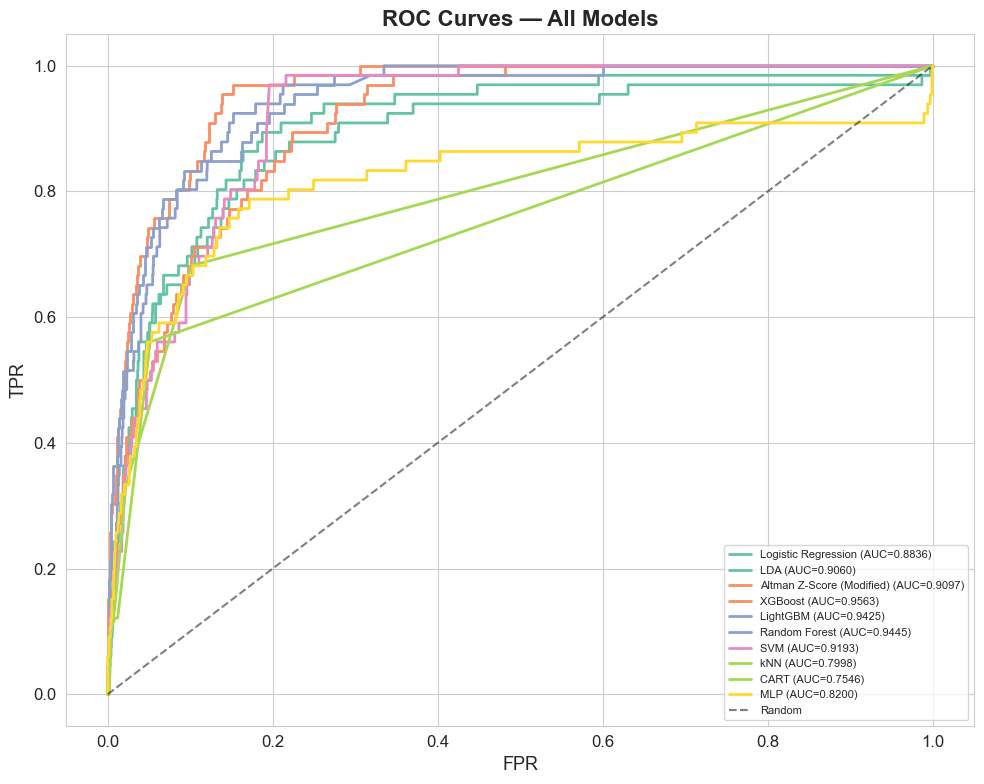

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))
for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.4f})", color=colors_plot[i % len(colors_plot)], linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax.set_xlabel('FPR', fontsize=13); ax.set_ylabel('TPR', fontsize=13)
ax.set_title('ROC Curves — All Models', fontsize=16, fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

### 7.2 KS Statistic

In [22]:
print('Kolmogorov-Smirnov (KS) Statistic:')
for name, res in sorted(results.items(), key=lambda x: x[1]['ks'], reverse=True):
    print(f"  {name:30s}  KS = {res['ks']:.4f}")

Kolmogorov-Smirnov (KS) Statistic:
  XGBoost                         KS = 0.8177
  SVM                             KS = 0.7737
  Random Forest                   KS = 0.7717
  LightGBM                        KS = 0.7404
  LDA                             KS = 0.7066
  Altman Z-Score (Modified)       KS = 0.6707
  Logistic Regression             KS = 0.6601
  MLP                             KS = 0.6162
  kNN                             KS = 0.5803
  CART                            KS = 0.5091


### 7.3 Confusion Matrices

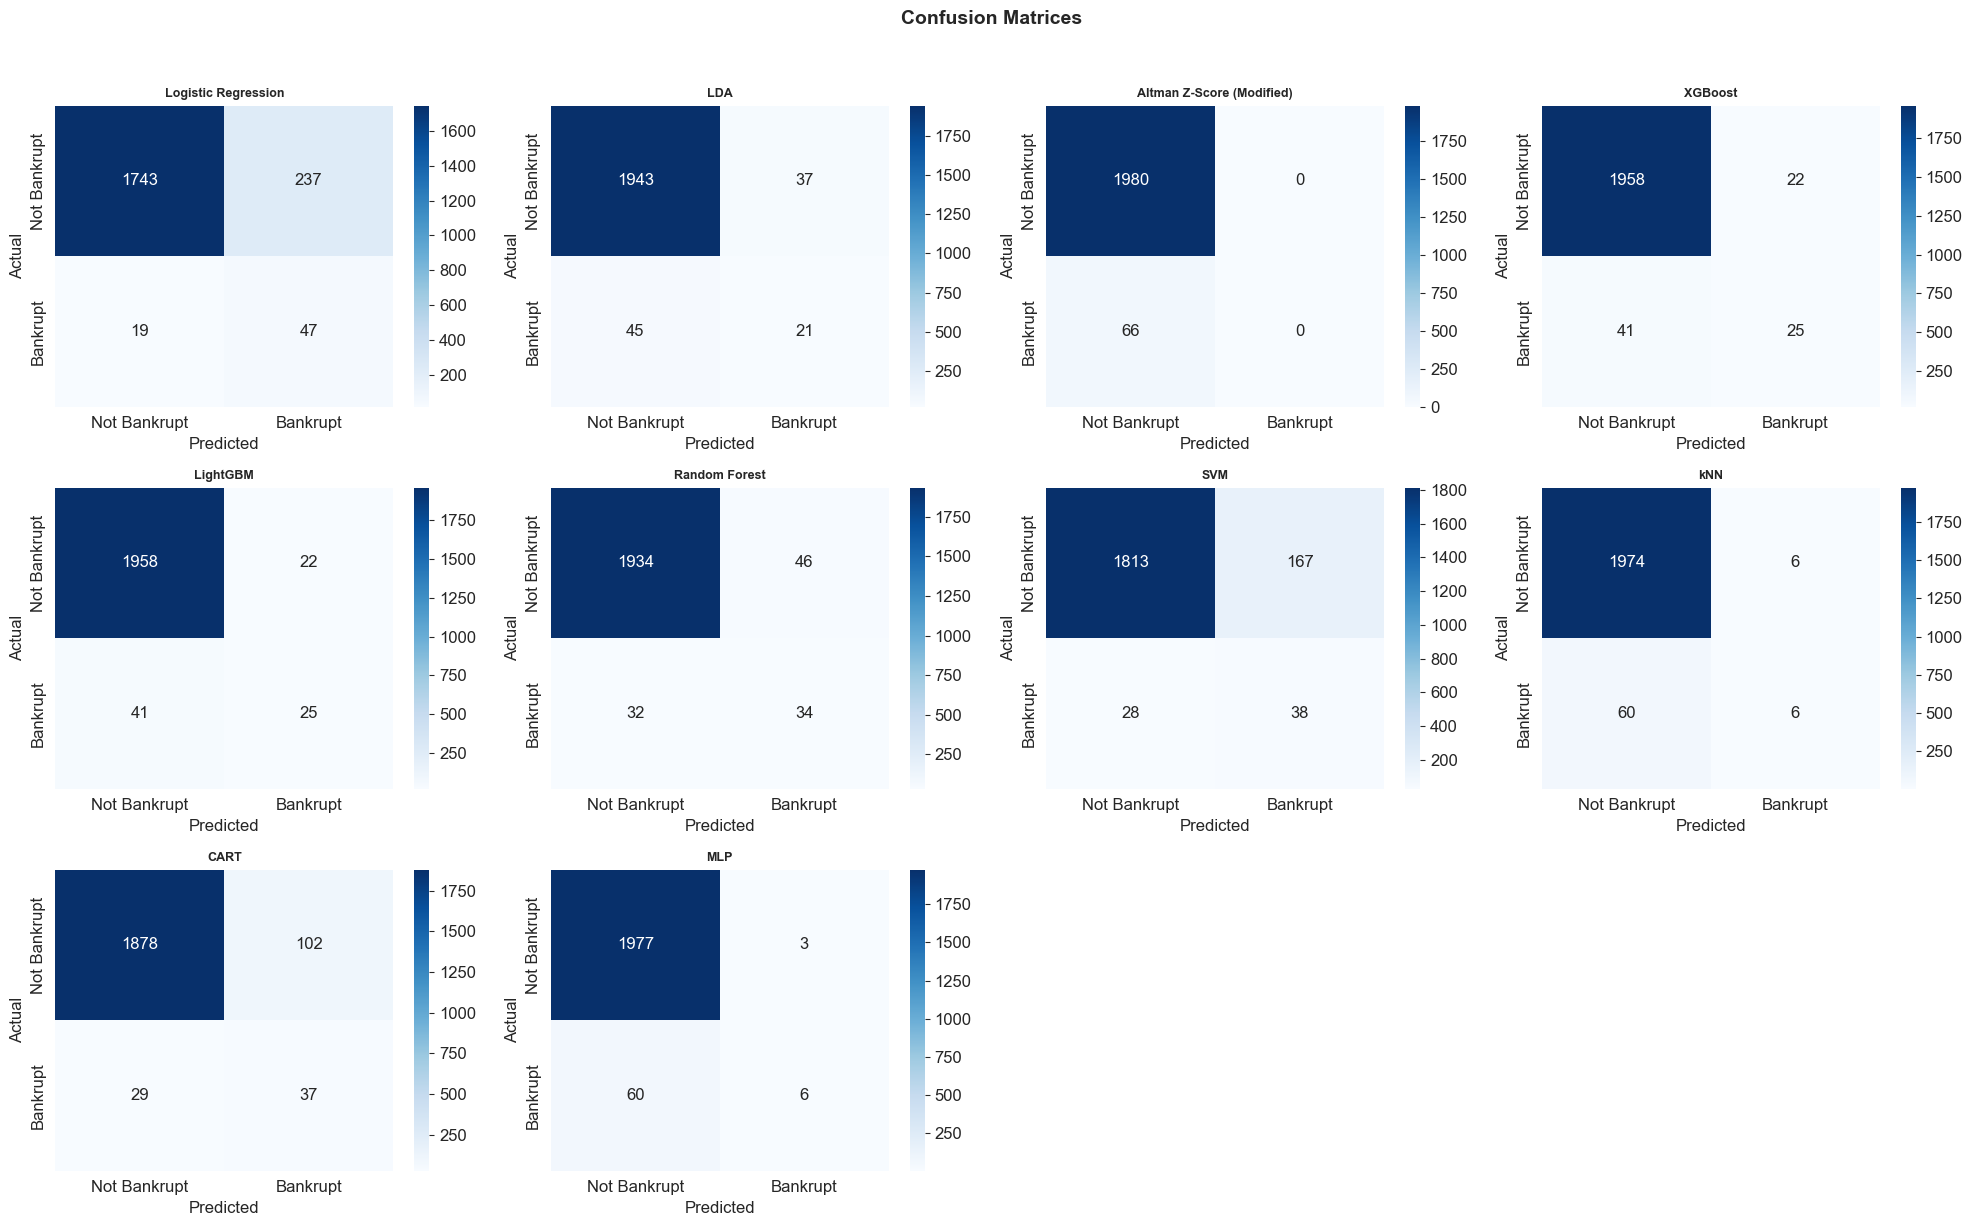

In [23]:
n = len(results); nc = 4; nr = (n + nc - 1) // nc
fig, axes = plt.subplots(nr, nc, figsize=(5*nc, 4*nr))
axes = axes.flatten()
for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Not Bankrupt', 'Bankrupt'], yticklabels=['Not Bankrupt', 'Bankrupt'])
    axes[i].set_title(name, fontweight='bold', fontsize=9)
    axes[i].set_ylabel('Actual'); axes[i].set_xlabel('Predicted')
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

### 7.4 Classification Reports

In [24]:
for name, res in results.items():
    print(f'\n=== {name} ({res["paradigm"]}) ===')
    print(classification_report(y_test, res['y_pred'], target_names=['Not Bankrupt', 'Bankrupt']))


=== Logistic Regression (Econometric) ===
              precision    recall  f1-score   support

Not Bankrupt       0.99      0.88      0.93      1980
    Bankrupt       0.17      0.71      0.27        66

    accuracy                           0.87      2046
   macro avg       0.58      0.80      0.60      2046
weighted avg       0.96      0.87      0.91      2046


=== LDA (Econometric) ===
              precision    recall  f1-score   support

Not Bankrupt       0.98      0.98      0.98      1980
    Bankrupt       0.36      0.32      0.34        66

    accuracy                           0.96      2046
   macro avg       0.67      0.65      0.66      2046
weighted avg       0.96      0.96      0.96      2046


=== Altman Z-Score (Modified) (Econometric) ===
              precision    recall  f1-score   support

Not Bankrupt       0.97      1.00      0.98      1980
    Bankrupt       0.00      0.00      0.00        66

    accuracy                           0.97      2046
   macro 

### 7.5 Gain Curve

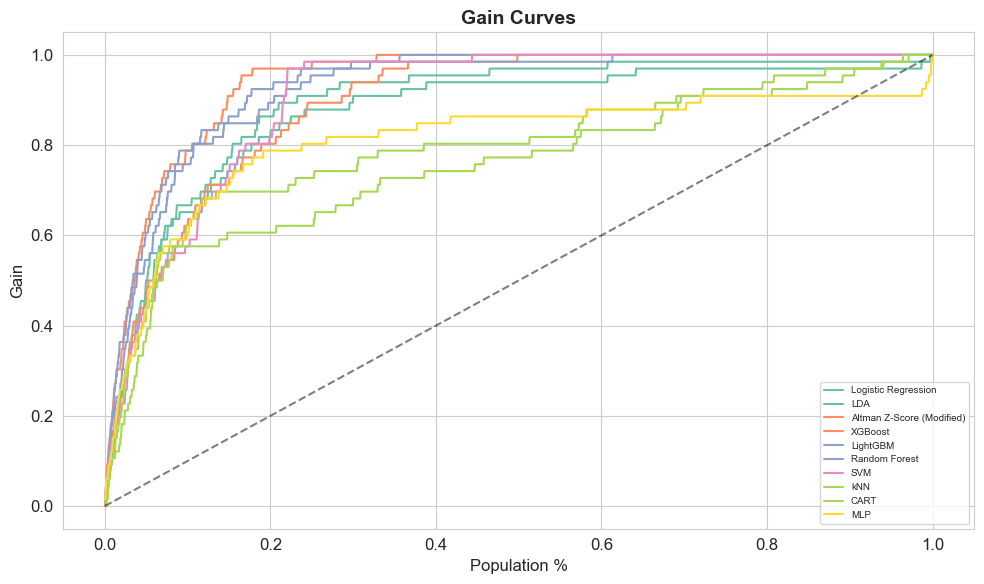

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
for i, (name, res) in enumerate(results.items()):
    si = np.argsort(-res['y_prob']); ys = y_test.values[si]
    cg = np.cumsum(ys) / ys.sum(); pp = np.arange(1, len(ys)+1) / len(ys)
    ax.plot(pp, cg, label=name, color=colors_plot[i % len(colors_plot)])
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('Population %'); ax.set_ylabel('Gain')
ax.set_title('Gain Curves', fontsize=14, fontweight='bold')
ax.legend(fontsize=7); plt.tight_layout(); plt.show()

### 7.6 PD Distribution

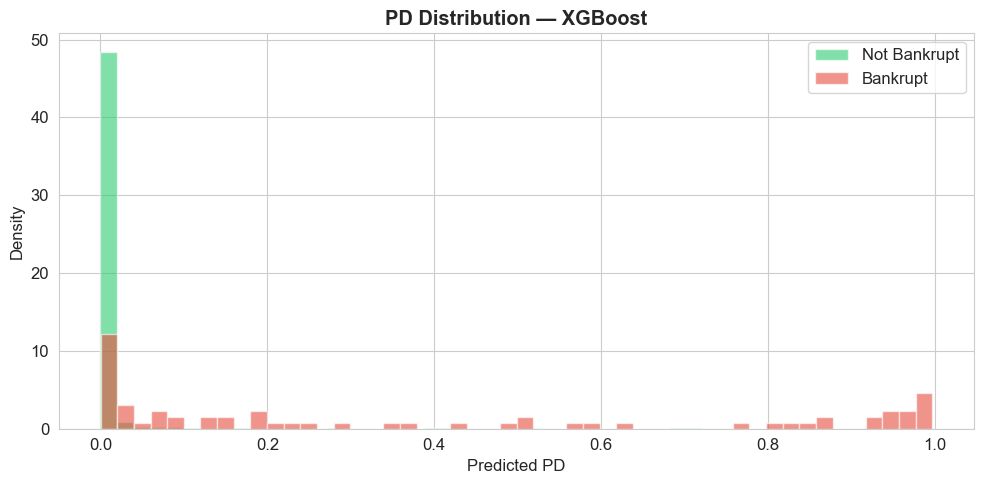

In [26]:
best_name = max(results.keys(), key=lambda k: results[k]['auc'])
bp = results[best_name]['y_prob']
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(bp[y_test==0], bins=50, alpha=0.6, label='Not Bankrupt', color='#2ecc71', density=True)
ax.hist(bp[y_test==1], bins=50, alpha=0.6, label='Bankrupt', color='#e74c3c', density=True)
ax.set_xlabel('Predicted PD'); ax.set_ylabel('Density')
ax.set_title(f'PD Distribution — {best_name}', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

---
## Phase 8 — Model Calibration
### 8.1 Calibration Curves

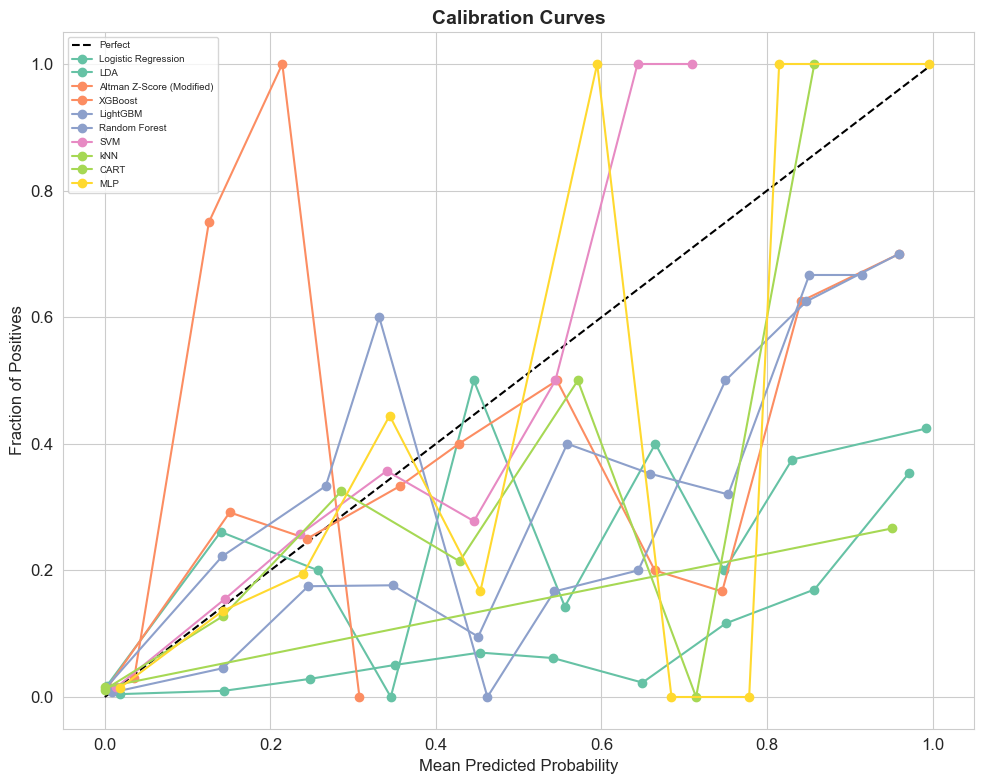

In [27]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
for i, (name, res) in enumerate(results.items()):
    try:
        pt, pp = calibration_curve(y_test, res['y_prob'], n_bins=10, strategy='uniform')
        ax.plot(pp, pt, marker='o', label=name, color=colors_plot[i % len(colors_plot)])
    except: pass
ax.set_xlabel('Mean Predicted Probability'); ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curves', fontsize=14, fontweight='bold')
ax.legend(fontsize=7); plt.tight_layout(); plt.show()

### 8.2 Brier Score

In [28]:
print('Brier Score (lower = better):')
for name, res in sorted(results.items(), key=lambda x: x[1]['brier']):
    print(f"  {name:30s}  Brier = {res['brier']:.6f}")

Brier Score (lower = better):
  XGBoost                         Brier = 0.024535
  LightGBM                        Brier = 0.024907
  SVM                             Brier = 0.026510
  MLP                             Brier = 0.026525
  kNN                             Brier = 0.027380
  Random Forest                   Brier = 0.029220
  Altman Z-Score (Modified)       Brier = 0.030121
  LDA                             Brier = 0.034145
  CART                            Brier = 0.059283
  Logistic Regression             Brier = 0.089456


### 8.3 Hosmer-Lemeshow Test

In [29]:
def hosmer_lemeshow(y_true, y_prob, g=10):
    data = pd.DataFrame({'y': y_true, 'p': y_prob})
    data['decile'] = pd.qcut(data['p'], q=g, duplicates='drop')
    t = data.groupby('decile', observed=True)['y'].agg(['count', 'sum'])
    t.columns = ['n', 'obs']; t['pred'] = data.groupby('decile', observed=True)['p'].sum()
    t['nobs'] = t['n'] - t['obs']; t['npred'] = t['n'] - t['pred']
    chi2 = ((t['obs']-t['pred'])**2 / t['pred']).sum() + ((t['nobs']-t['npred'])**2 / t['npred']).sum()
    return chi2, 1 - stats.chi2.cdf(chi2, g - 2)

print('Hosmer-Lemeshow (p > 0.05 = good fit):')
for name, res in results.items():
    try:
        c, p = hosmer_lemeshow(y_test.values, res['y_prob'])
        v = 'GOOD' if p > 0.05 else 'POOR'
        print(f"  {name:30s}  χ²={c:8.3f}  p={p:.4f}  [{v}]")
    except:
        print(f"  {name:30s}  N/A")

Hosmer-Lemeshow (p > 0.05 = good fit):
  Logistic Regression             χ²=2912.798  p=0.0000  [POOR]
  LDA                             χ²= 670.695  p=0.0000  [POOR]
  Altman Z-Score (Modified)       χ²= 124.007  p=0.0000  [POOR]
  XGBoost                         χ²= 246.516  p=0.0000  [POOR]
  LightGBM                        χ²=3840.646  p=0.0000  [POOR]
  Random Forest                   χ²=  40.566  p=0.0000  [POOR]
  SVM                             χ²=  21.404  p=0.0061  [POOR]
  kNN                             χ²=  13.651  p=0.0913  [GOOD]
  CART                            χ²=  35.374  p=0.0000  [POOR]
  MLP                             χ²=4044.443  p=0.0000  [POOR]


---
## Phase 9 — Post-Model Calibration

In [30]:
best_ml = max([k for k, v in results.items() if v['paradigm'] == 'ML'], key=lambda k: results[k]['auc'])
print(f'Post-calibration for: {best_ml}')
uses_s = best_ml in ['SVM', 'kNN', 'MLP']
Xtr = X_train_sel_scaled if uses_s else X_train_sel
Xte = X_test_sel_scaled if uses_s else X_test_sel

for method, label in [('sigmoid', 'Platt Scaling'), ('isotonic', 'Isotonic Regression')]:
    try:
        base = results[best_ml]['model'].__class__(**results[best_ml]['model'].get_params())
        cal = CalibratedClassifierCV(base, method=method, cv=3)
        cal.fit(Xtr, y_train)
        yp = cal.predict_proba(Xte)[:, 1]
        b = brier_score_loss(y_test, yp)
        print(f'  {label}: Brier={b:.6f} (original: {results[best_ml]["brier"]:.6f})')
    except Exception as e:
        print(f'  {label}: Failed — {e}')

Post-calibration for: XGBoost
  Platt Scaling: Brier=0.022452 (original: 0.024535)
  Isotonic Regression: Brier=0.021336 (original: 0.024535)


---
## Phase 10 — Interpretability (SHAP)

In [31]:
tree_models = {k: v for k, v in results.items() if k in ['XGBoost', 'LightGBM', 'Random Forest', 'CART']}
best_tree = max(tree_models.keys(), key=lambda k: tree_models[k]['auc'])
print(f'SHAP analysis for: {best_tree}')

explainer = shap.TreeExplainer(results[best_tree]['model'])
X_shap = X_test_sel.sample(min(500, len(X_test_sel)), random_state=42)
sv = explainer.shap_values(X_shap)
if isinstance(sv, list): sv = sv[1]

SHAP analysis for: XGBoost


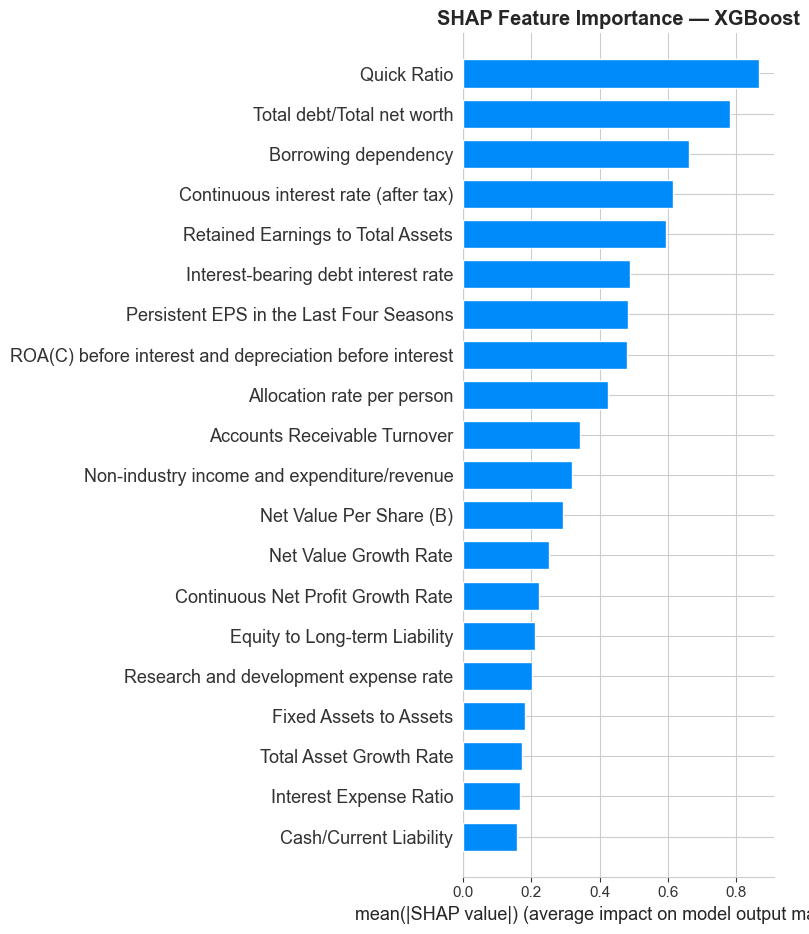

In [32]:
plt.figure(figsize=(12, 10))
shap.summary_plot(sv, X_shap, plot_type='bar', show=False, max_display=20)
plt.title(f'SHAP Feature Importance — {best_tree}', fontweight='bold')
plt.tight_layout(); plt.show()

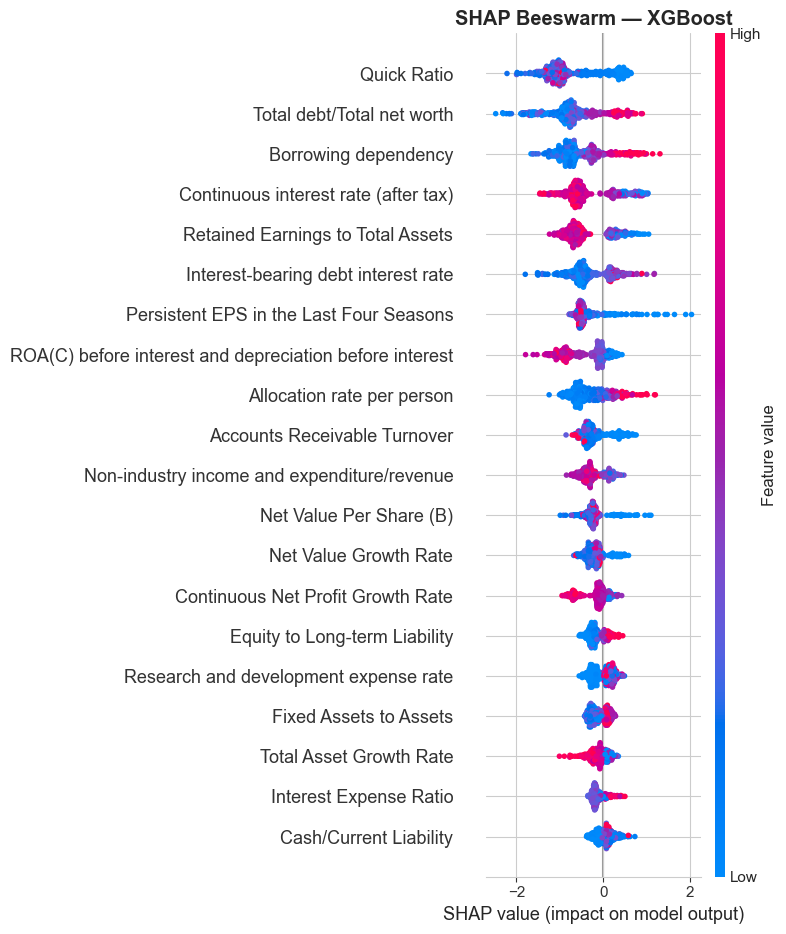

In [33]:
plt.figure(figsize=(12, 10))
shap.summary_plot(sv, X_shap, show=False, max_display=20)
plt.title(f'SHAP Beeswarm — {best_tree}', fontweight='bold')
plt.tight_layout(); plt.show()

---
## Phase 11 — Final Comparative Summary

In [34]:
comp = pd.DataFrame({
    'Model': list(results.keys()),
    'Paradigm': [results[k]['paradigm'] for k in results],
    'Accuracy': [results[k]['accuracy'] for k in results],
    'AUC': [results[k]['auc'] for k in results],
    'Gini': [results[k]['gini'] for k in results],
    'KS': [results[k]['ks'] for k in results],
    'F1': [results[k]['f1'] for k in results],
    'Precision': [results[k]['precision'] for k in results],
    'Recall': [results[k]['recall'] for k in results],
    'Brier': [results[k]['brier'] for k in results],
}).sort_values('AUC', ascending=False).reset_index(drop=True)
comp.index += 1; comp.index.name = 'Rank'

print('=== FINAL MODEL COMPARISON — Taiwanese Bankruptcy Prediction ===')
print(comp.to_string())

=== FINAL MODEL COMPARISON — Taiwanese Bankruptcy Prediction ===
                          Model     Paradigm  Accuracy       AUC      Gini        KS        F1  Precision    Recall     Brier
Rank                                                                                                                         
1                       XGBoost           ML  0.969208  0.956252  0.912504  0.817677  0.442478   0.531915  0.378788  0.024535
2                 Random Forest           ML  0.961877  0.944513  0.889027  0.771717  0.465753   0.425000  0.515152  0.029220
3                      LightGBM           ML  0.969208  0.942470  0.884940  0.740404  0.442478   0.531915  0.378788  0.024907
4                           SVM           ML  0.904692  0.919295  0.838590  0.773737  0.280443   0.185366  0.575758  0.026510
5     Altman Z-Score (Modified)  Econometric  0.967742  0.909688  0.819376  0.670707  0.000000   0.000000  0.000000  0.030121
6                           LDA  Econometric  0.95992

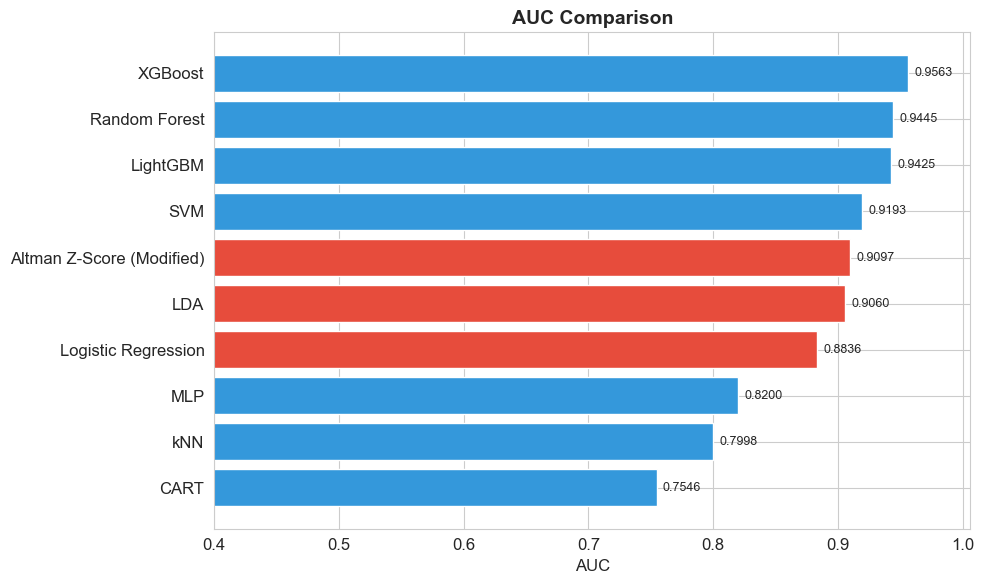

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))
pcol = {'Econometric': '#e74c3c', 'ML': '#3498db'}
bc = [pcol.get(results[m]['paradigm'], '#95a5a6') for m in comp['Model']]
bars = ax.barh(comp['Model'], comp['AUC'], color=bc)
ax.set_xlabel('AUC'); ax.set_title('AUC Comparison', fontsize=14, fontweight='bold')
ax.set_xlim([0.4, max(comp['AUC'])+0.05]); ax.invert_yaxis()
for b, v in zip(bars, comp['AUC']): ax.text(v+0.005, b.get_y()+b.get_height()/2, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

### FICO Score Mapping

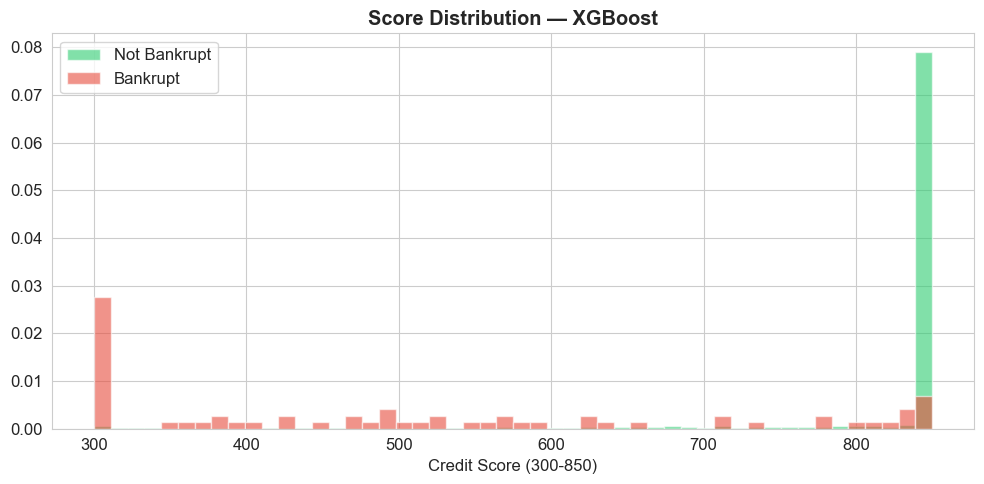

Non-bankrupt: mean=824  |  Bankrupt: mean=513


In [36]:
def pd_to_score(pd_val, pdo=50, base_score=600, base_odds=19):
    pd_val = np.clip(pd_val, 0.001, 0.999)
    odds = (1 - pd_val) / pd_val
    factor = pdo / np.log(2)
    offset = base_score - factor * np.log(base_odds)
    return np.clip(offset + factor * np.log(odds), 300, 850)

scores = pd_to_score(results[best_name]['y_prob'])
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(scores[y_test==0], bins=50, alpha=0.6, label='Not Bankrupt', color='#2ecc71', density=True)
ax.hist(scores[y_test==1], bins=50, alpha=0.6, label='Bankrupt', color='#e74c3c', density=True)
ax.set_xlabel('Credit Score (300-850)'); ax.set_title(f'Score Distribution — {best_name}', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Non-bankrupt: mean={scores[y_test==0].mean():.0f}  |  Bankrupt: mean={scores[y_test==1].mean():.0f}')

### Discussion

1. **Paradigm 1 (Econometric)**: Logistic Regression/Probit provide interpretable baselines.
   The Modified Altman Z-Score uses a book-value proxy for X₄ (no market data available),
   which weakens its discriminatory power compared to the original formulation.

2. **Paradigm 2 (ML)**: Gradient boosting (XGBoost/LightGBM) handles the 95-feature space and
   severe class imbalance well. Feature importance reveals which financial ratios matter most.

3. **Paradigm 3 (Structural)**: Impossible — no market equity data (stock prices, volatility).

4. **Paradigm 4 (Dynamic)**: Impossible — no panel/longitudinal structure.

#### Key Takeaway for Bank of Africa
This corporate bankruptcy dataset is directly analogous to BOA's corporate loan portfolio.
The analysis shows that financial ratio-based models can effectively predict corporate distress,
with ML models offering superior discrimination but classical models providing regulatory-compliant interpretability.

---
## End of Analysis